In [1]:
# pip install scikit-learn -U

In [2]:
import pandas as pd
import numpy as np
import seaborn as sbn
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import LabelEncoder
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv(r'../datasets/Loan_approval_data_2025.csv')

In [4]:
loan_df = df.drop(labels = 'customer_id', axis = 1)

# EDA

In [5]:
loan_df.head()

,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Credit Card,Business,600,17.02,0.423,0.023,0.008,1
1,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,0
2,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,0.101,0.034,1
3,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,1
4,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,1


In [6]:
loan_df.shape

(50000, 19)

In [7]:
loan_df.describe()

,age,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.957060,7.454868,50062.892040,643.614820,8.168274,3595.619400,14290.442220,0.053480,0.55464,0.147640,33041.874000,15.498591,0.285724,0.701999,0.233995,0.550460
std,11.118603,7.612097,32630.501014,64.731518,7.207552,13232.399398,13243.757493,0.224991,0.84505,0.412996,26116.185102,4.067942,0.159787,0.465788,0.155268,0.497452
min,18.000000,0.000000,15000.000000,348.000000,0.000000,0.000000,60.000000,0.000000,0.00000,0.000000,500.000000,6.000000,0.002000,0.008000,0.003000,0.000000
25%,26.000000,1.300000,27280.500000,600.000000,2.000000,130.000000,5581.000000,0.000000,0.00000,0.000000,12300.000000,12.180000,0.161000,0.333000,0.111000,0.000000
50%,35.000000,4.900000,41607.500000,643.000000,6.100000,568.000000,10385.000000,0.000000,0.00000,0.000000,26100.000000,15.440000,0.265000,0.622000,0.207000,1.000000
75%,43.000000,11.400000,62723.250000,687.000000,12.600000,2271.000000,18449.250000,0.000000,1.00000,0.000000,48500.000000,18.870000,0.389000,1.010250,0.337000,1.000000
max,70.000000,39.900000,250000.000000,850.000000,30.000000,300000.000000,163344.000000,1.000000,9.00000,4.000000,100000.000000,23.000000,0.800000,2.001000,0.667000,1.000000


In [8]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      50000 non-null  int64  
 1   occupation_status        50000 non-null  object 
 2   years_employed           50000 non-null  float64
 3   annual_income            50000 non-null  int64  
 4   credit_score             50000 non-null  int64  
 5   credit_history_years     50000 non-null  float64
 6   savings_assets           50000 non-null  int64  
 7   current_debt             50000 non-null  int64  
 8   defaults_on_file         50000 non-null  int64  
 9   delinquencies_last_2yrs  50000 non-null  int64  
 10  derogatory_marks         50000 non-null  int64  
 11  product_type             50000 non-null  object 
 12  loan_intent              50000 non-null  object 
 13  loan_amount              50000 non-null  int64  
 14  interest_rate         

In [9]:
loan_df.isnull().sum()

age                        0
occupation_status          0
years_employed             0
annual_income              0
credit_score               0
credit_history_years       0
savings_assets             0
current_debt               0
defaults_on_file           0
delinquencies_last_2yrs    0
derogatory_marks           0
product_type               0
loan_intent                0
loan_amount                0
interest_rate              0
debt_to_income_ratio       0
loan_to_income_ratio       0
payment_to_income_ratio    0
loan_status                0
dtype: int64

In [10]:
loan_df.columns

Index(['age', 'occupation_status', 'years_employed', 'annual_income',
       'credit_score', 'credit_history_years', 'savings_assets',
       'current_debt', 'defaults_on_file', 'delinquencies_last_2yrs',
       'derogatory_marks', 'product_type', 'loan_intent', 'loan_amount',
       'interest_rate', 'debt_to_income_ratio', 'loan_to_income_ratio',
       'payment_to_income_ratio', 'loan_status'],
      dtype='object')

In [11]:
encoder = LabelEncoder()
loan_df['occupation_status'] = encoder.fit_transform(loan_df['occupation_status'])
loan_df['product_type'] = encoder.fit_transform(loan_df['product_type'])
loan_df['loan_intent'] = encoder.fit_transform(loan_df['loan_intent'])

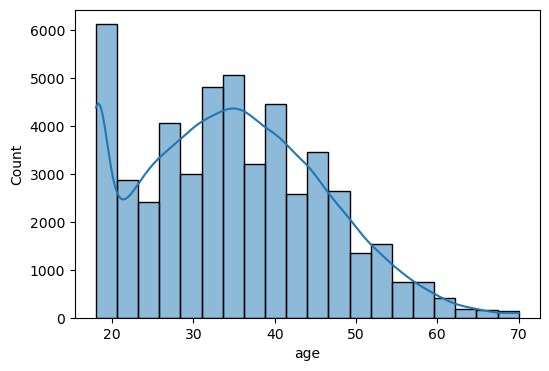

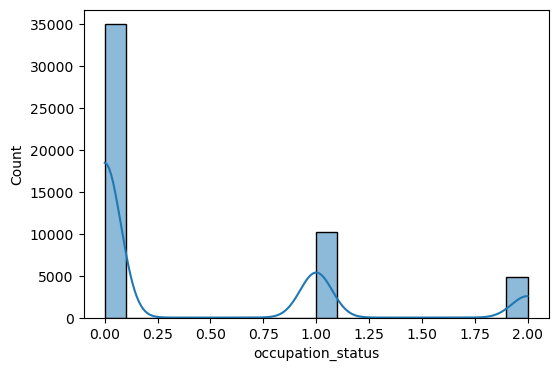

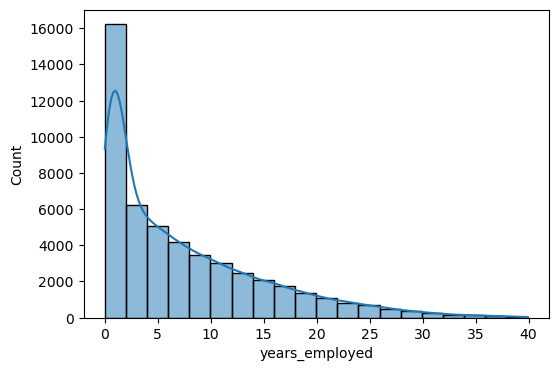

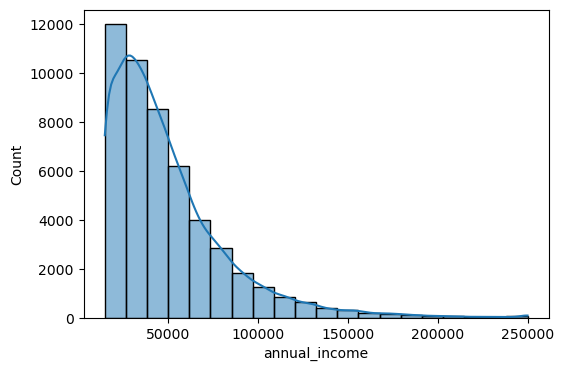

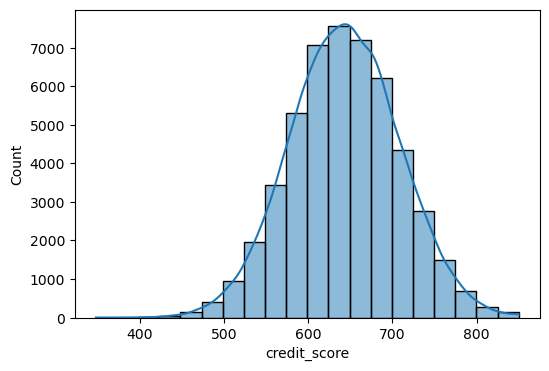

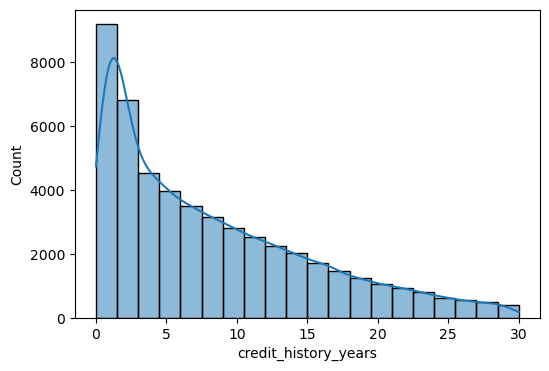

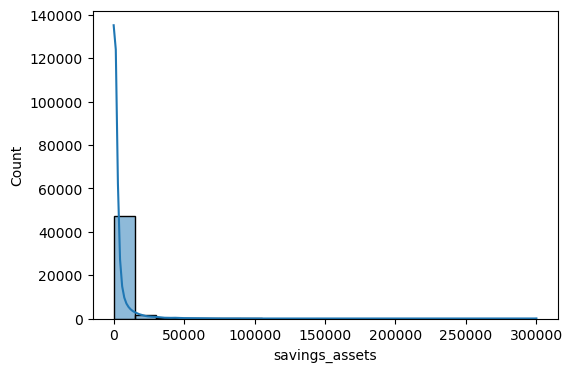

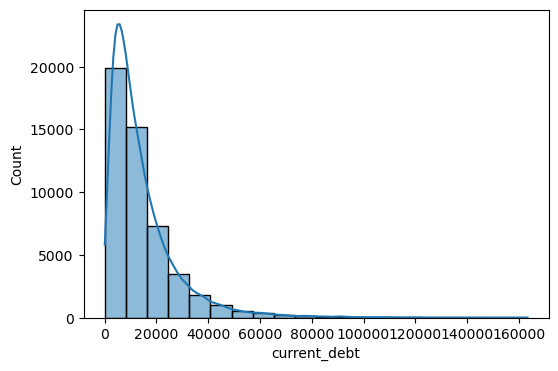

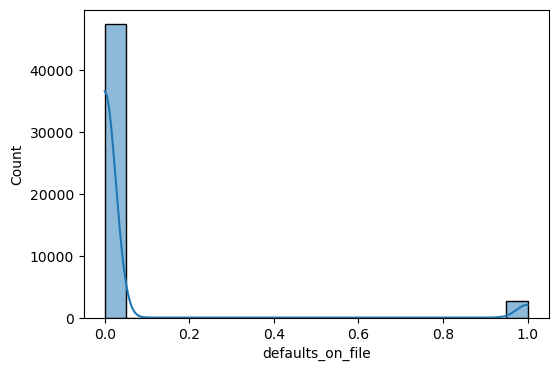

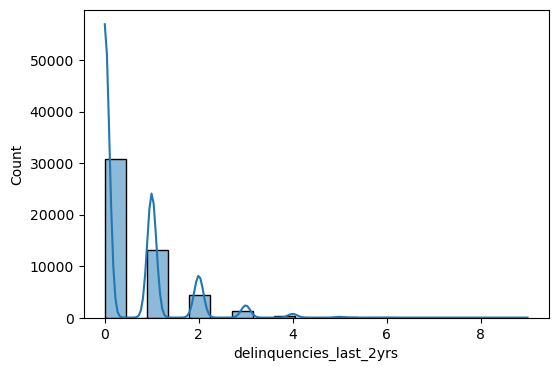

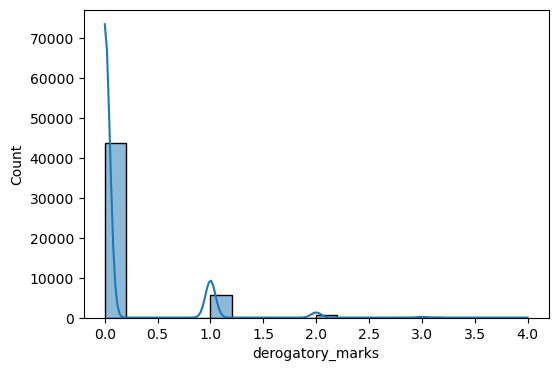

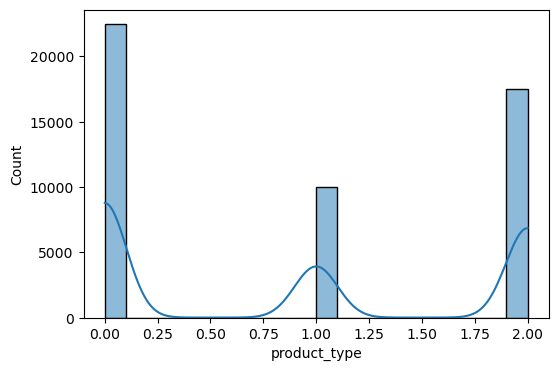

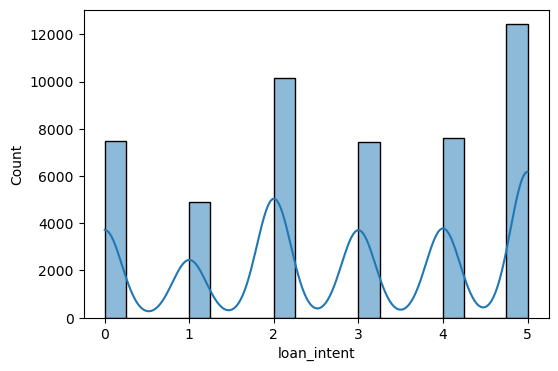

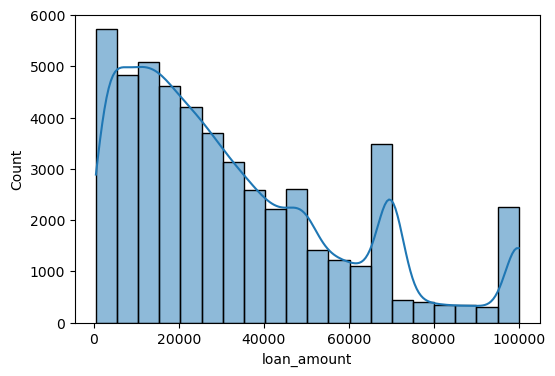

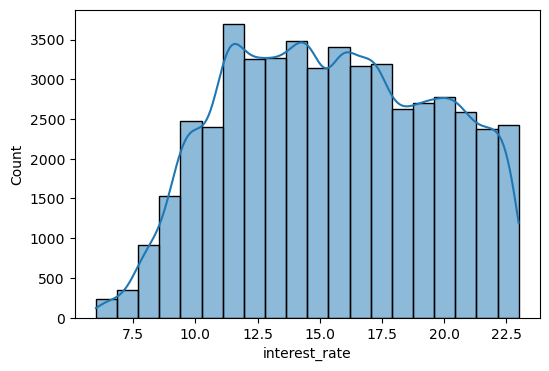

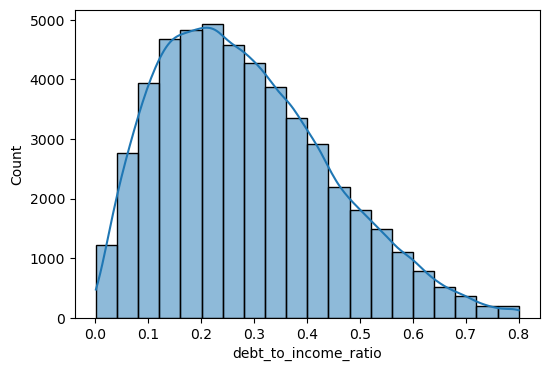

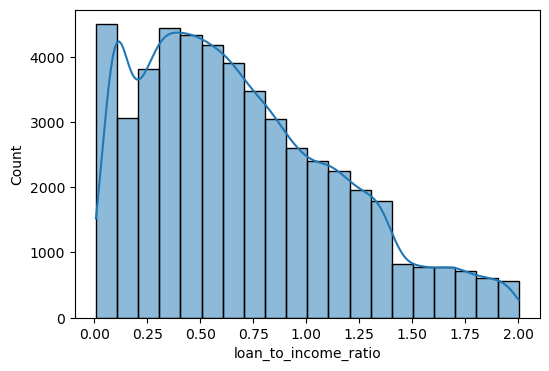

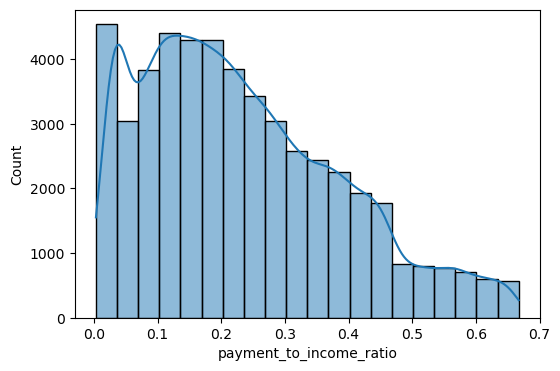

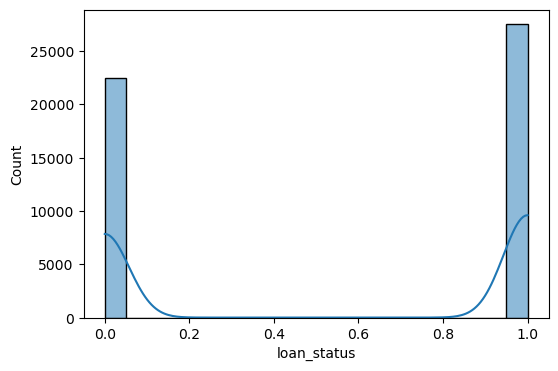

In [12]:
numeric_colums = loan_df.select_dtypes(include='number')
for col in numeric_colums:
    plt.figure(figsize = (6,4))
    sbn.histplot(loan_df[col],kde = True, bins = 20)

In [13]:
min_values = loan_df.min(numeric_only=True)
max_values = loan_df.max(numeric_only=True)

print("Min values:\n", min_values)
print("\nMax values:\n", max_values)

Min values:
 age                           18.000
occupation_status              0.000
years_employed                 0.000
annual_income              15000.000
credit_score                 348.000
credit_history_years           0.000
savings_assets                 0.000
current_debt                  60.000
defaults_on_file               0.000
delinquencies_last_2yrs        0.000
derogatory_marks               0.000
product_type                   0.000
loan_intent                    0.000
loan_amount                  500.000
interest_rate                  6.000
debt_to_income_ratio           0.002
loan_to_income_ratio           0.008
payment_to_income_ratio        0.003
loan_status                    0.000
dtype: float64

Max values:
 age                            70.000
occupation_status               2.000
years_employed                 39.900
annual_income              250000.000
credit_score                  850.000
credit_history_years           30.000
savings_assets             

<Axes: >

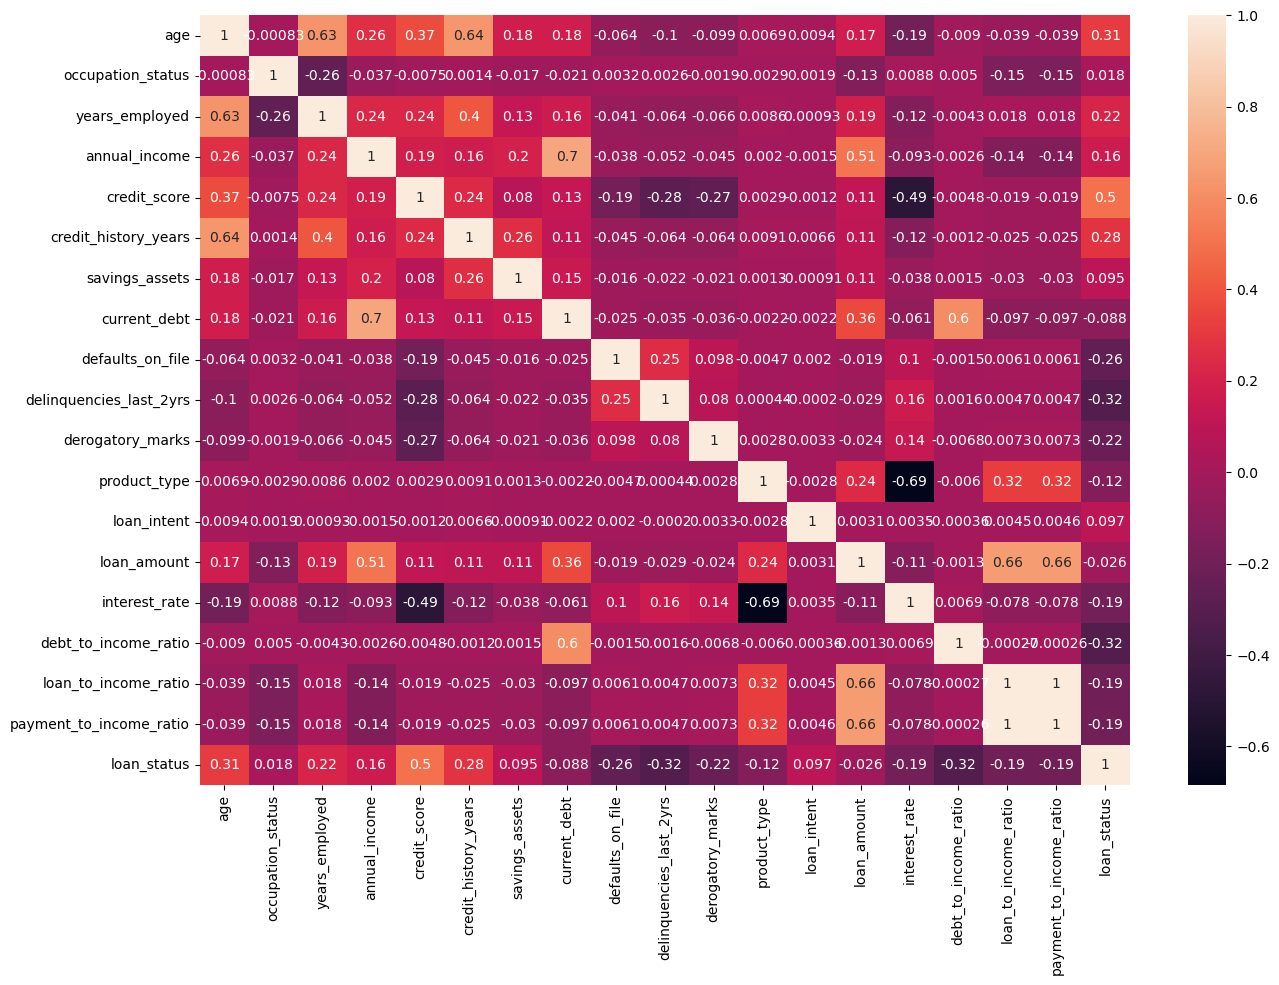

In [14]:
plt.figure(figsize = (15,10))
sbn.heatmap(loan_df.corr(numeric_only = True),annot=True)

# data cleaning and preprocessing

In [15]:
loan_df.drop_duplicates(inplace=True)

In [16]:
loan_df.shape

(50000, 19)

In [17]:
from sklearn.preprocessing import StandardScaler

# feature Engineering

In [18]:
final_loan = loan_df.copy()


In [19]:
# diabeties_df
# scaled_df
final_loan.columns

Index(['age', 'occupation_status', 'years_employed', 'annual_income',
       'credit_score', 'credit_history_years', 'savings_assets',
       'current_debt', 'defaults_on_file', 'delinquencies_last_2yrs',
       'derogatory_marks', 'product_type', 'loan_intent', 'loan_amount',
       'interest_rate', 'debt_to_income_ratio', 'loan_to_income_ratio',
       'payment_to_income_ratio', 'loan_status'],
      dtype='object')

In [20]:
final_loan['credit_risk_score'] = (
    final_loan['defaults_on_file'] +
    final_loan['delinquencies_last_2yrs'] +
    final_loan['derogatory_marks']
)

In [21]:
final_loan['stability_score'] = final_loan['annual_income'] / (final_loan['current_debt'] + 1)

In [22]:
final_loan['income_strength'] = final_loan['annual_income'] * final_loan['years_employed']

In [23]:
final_loan['credit_experience'] = final_loan['credit_history_years'] / (final_loan['age'] + 1)

In [24]:
final_loan['debt_burden'] = final_loan['current_debt'] / (final_loan['annual_income'] + 1)

In [25]:
final_loan['asset_cushion'] = final_loan['savings_assets'] / (final_loan['loan_amount'] + 1)

In [26]:
final_loan.head()

,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,...,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status,credit_risk_score,stability_score,income_strength,credit_experience,debt_burden,asset_cushion
0,40,0,17.2,25579,692,5.3,895,10820,0,0,...,0.423,0.023,0.008,1,0,2.363830,439958.8,0.129268,0.422987,1.489185
1,33,0,7.3,43087,627,3.5,169,16550,0,1,...,0.384,1.237,0.412,0,1,2.603287,314535.1,0.102941,0.384098,0.003171
2,42,2,1.1,20840,689,8.4,17,7852,0,0,...,0.377,0.101,0.034,1,0,2.653763,22924.0,0.195349,0.376757,0.008091
3,53,2,0.5,29147,692,9.8,1480,11603,0,1,...,0.398,0.099,0.033,1,1,2.511806,14573.5,0.181481,0.398072,0.510169
4,32,0,12.5,63657,630,7.2,209,12424,0,0,...,0.195,1.565,0.522,1,0,5.123300,795712.5,0.218182,0.195168,0.002098


<Axes: >

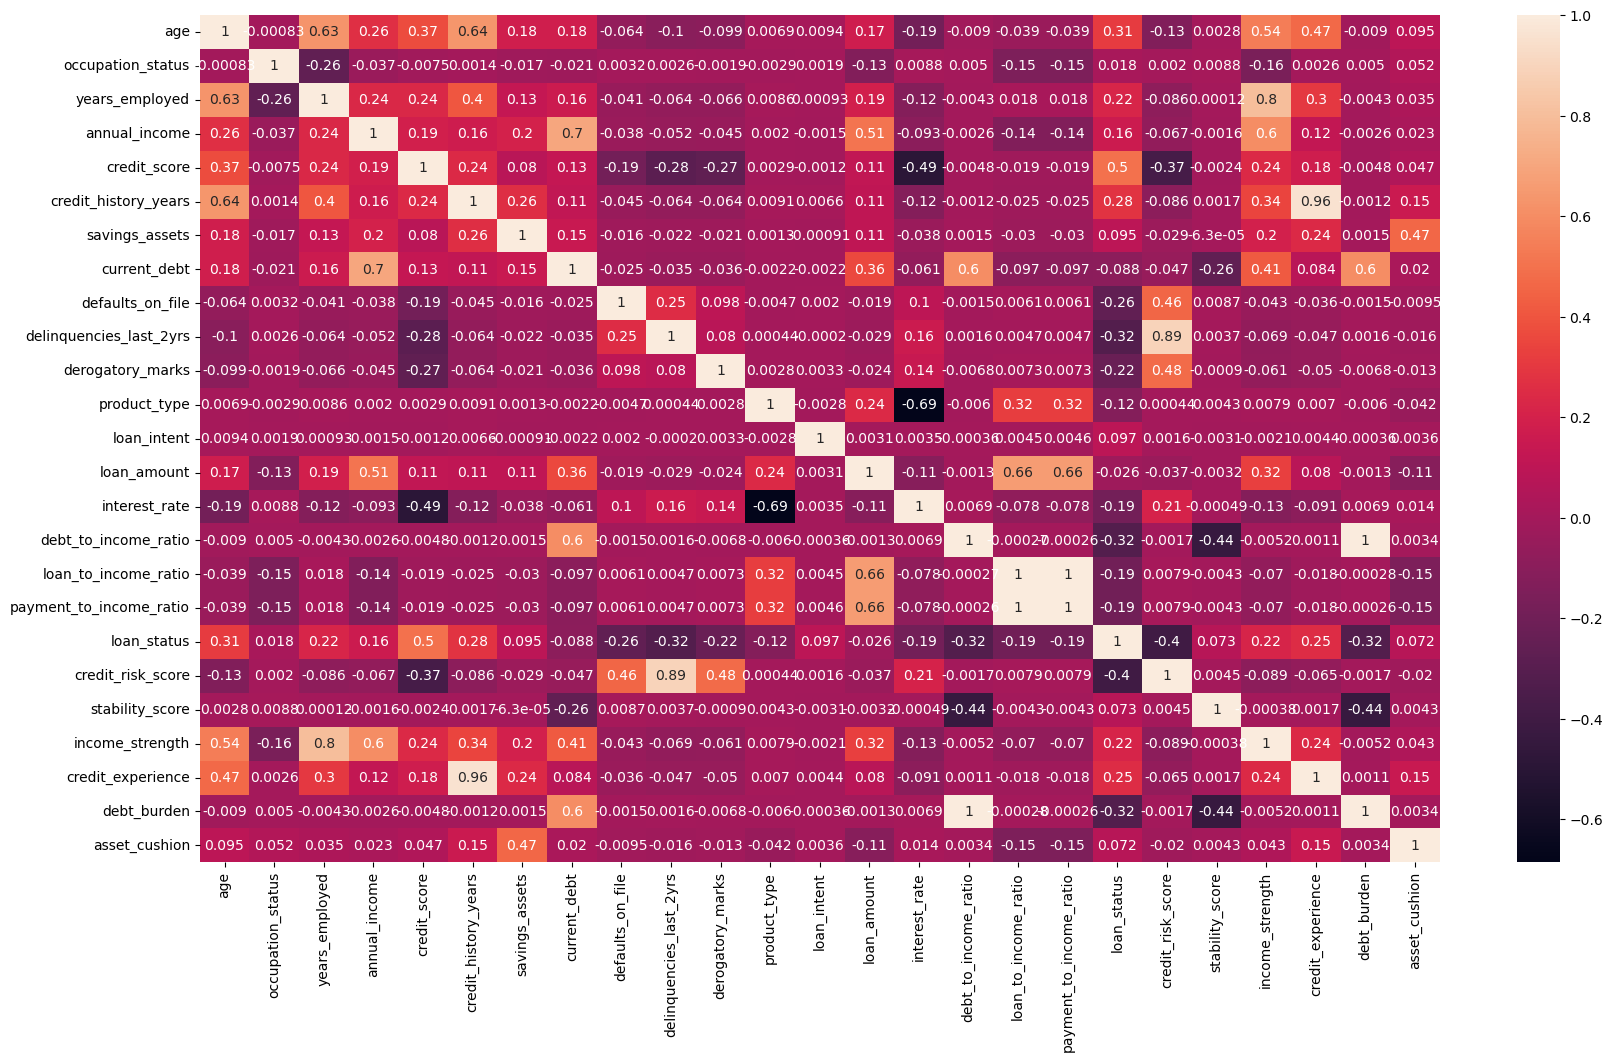

In [30]:
plt.figure(figsize = (20,11))
sbn.heatmap(final_loan.corr(numeric_only = True),annot=True)

In [28]:
final_loan.columns

Index(['age', 'occupation_status', 'years_employed', 'annual_income',
       'credit_score', 'credit_history_years', 'savings_assets',
       'current_debt', 'defaults_on_file', 'delinquencies_last_2yrs',
       'derogatory_marks', 'product_type', 'loan_intent', 'loan_amount',
       'interest_rate', 'debt_to_income_ratio', 'loan_to_income_ratio',
       'payment_to_income_ratio', 'loan_status', 'credit_risk_score',
       'stability_score', 'income_strength', 'credit_experience',
       'debt_burden', 'asset_cushion'],
      dtype='object')

In [32]:
loan_data = final_loan[['credit_score',
        'credit_risk_score',
        'debt_to_income_ratio',
        'credit_history_years',
        'years_employed',
        'annual_income',
        'stability_score','loan_status']]

In [33]:
loan_data.head()

,credit_score,credit_risk_score,debt_to_income_ratio,credit_history_years,years_employed,annual_income,stability_score,loan_status
0,692,0,0.423,5.3,17.2,25579,2.363830,1
1,627,1,0.384,3.5,7.3,43087,2.603287,0
2,689,0,0.377,8.4,1.1,20840,2.653763,1
3,692,1,0.398,9.8,0.5,29147,2.511806,1
4,630,0,0.195,7.2,12.5,63657,5.123300,1


# model training

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_predict

In [35]:
scaler = StandardScaler()


In [36]:
X = loan_data.drop(labels = 'loan_status', axis = 1)
y = loan_data['loan_status']
scaled_data = scaler.fit_transform(X)
X_scaled = pd.DataFrame(scaled_data, columns=X.columns)
X_scaled.head()

,credit_score,credit_risk_score,debt_to_income_ratio,credit_history_years,years_employed,annual_income,stability_score
0,0.747482,-0.718766,0.859129,-0.397958,1.280229,-0.750345,-0.354892
1,-0.256675,0.232285,0.615051,-0.647698,-0.020345,-0.213787,-0.331523
2,0.701137,-0.718766,0.571242,0.032151,-0.834846,-0.895579,-0.326597
3,0.747482,0.232285,0.702669,0.226393,-0.913669,-0.640998,-0.340451
4,-0.210330,-0.718766,-0.567789,-0.134343,0.662785,0.416612,-0.085590


In [37]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42)

# logistic reggression

In [38]:
LR_model = LogisticRegression(max_iter=1000)

In [39]:
LR_model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [40]:
y_predict = LR_model.predict(X_test)

In [41]:
y_predict

array([1, 1, 0, ..., 0, 1, 0], shape=(10000,))

In [42]:
y_test

33553    1
9427     1
199      0
12447    0
39489    1
        ..
28567    1
25079    1
18707    0
15200    1
5857     0
Name: loan_status, Length: 10000, dtype: int64

In [43]:
print("Accuracy:", accuracy_score(y_test, y_predict))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_predict))
print("\nClassification Report:\n", classification_report(y_test, y_predict))

Accuracy: 0.8167

Confusion Matrix:
 [[3510  999]
 [ 834 4657]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.78      0.79      4509
           1       0.82      0.85      0.84      5491

    accuracy                           0.82     10000
   macro avg       0.82      0.81      0.81     10000
weighted avg       0.82      0.82      0.82     10000



In [44]:
y_predictM = cross_val_predict(LR_model, X_scaled, y, cv=5)

In [45]:
y_predictM

array([1, 0, 1, ..., 1, 0, 1], shape=(50000,))

In [46]:
print("Accuracy:", accuracy_score(y, y_predictM))
print("\nConfusion Matrix:\n", confusion_matrix(y, y_predictM))
print("\nClassification Report:\n", classification_report(y, y_predictM))

Accuracy: 0.81302

Confusion Matrix:
 [[17365  5112]
 [ 4237 23286]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.77      0.79     22477
           1       0.82      0.85      0.83     27523

    accuracy                           0.81     50000
   macro avg       0.81      0.81      0.81     50000
weighted avg       0.81      0.81      0.81     50000



# Support Vector Machine

In [47]:
from sklearn.svm import SVC

In [48]:
SVC_model = SVC(kernel='rbf', class_weight='balanced')

In [49]:
y_predict_SVCt = SVC_model.fit(X_train, y_train)

In [50]:
y_predict_SVCtest = SVC_model.predict(X_test)

In [51]:
print("Accuracy:", accuracy_score(y_test, y_predict_SVCtest))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_predict_SVCtest))
print("\nClassification Report:\n", classification_report(y_test, y_predict_SVCtest))

Accuracy: 0.8434

Confusion Matrix:
 [[3776  733]
 [ 833 4658]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.84      0.83      4509
           1       0.86      0.85      0.86      5491

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



In [52]:
y_predictSVC = cross_val_predict(SVC_model, X_scaled, y, cv=5)

In [53]:
print("Accuracy:", accuracy_score(y, y_predictSVC))
print("\nConfusion Matrix:\n", confusion_matrix(y, y_predictSVC))
print("\nClassification Report:\n", classification_report(y, y_predictSVC))

Accuracy: 0.84092

Confusion Matrix:
 [[18726  3751]
 [ 4203 23320]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.83      0.82     22477
           1       0.86      0.85      0.85     27523

    accuracy                           0.84     50000
   macro avg       0.84      0.84      0.84     50000
weighted avg       0.84      0.84      0.84     50000



# random Forest

In [54]:
from sklearn.ensemble import RandomForestClassifier

In [55]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight = 'balanced')

In [56]:
y_predict_RF = rf_model.fit(X_train, y_train)

In [57]:
y_predict = y_predict_RF.predict(X_test)

In [58]:
print("Accuracy:", accuracy_score(y_test, y_predict))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_predict))
print("\nClassification Report:\n", classification_report(y_test, y_predict))

Accuracy: 0.8519

Confusion Matrix:
 [[3651  858]
 [ 623 4868]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.81      0.83      4509
           1       0.85      0.89      0.87      5491

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



In [59]:
y_predict_rf = cross_val_predict(rf_model, X, y, cv=5)

In [60]:
print("Accuracy:", accuracy_score(y, y_predict_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y, y_predict_rf))
print("\nClassification Report:\n", classification_report(y, y_predict_rf))

Accuracy: 0.84542

Confusion Matrix:
 [[18073  4404]
 [ 3325 24198]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.80      0.82     22477
           1       0.85      0.88      0.86     27523

    accuracy                           0.85     50000
   macro avg       0.85      0.84      0.84     50000
weighted avg       0.85      0.85      0.85     50000



# XgBoost

In [61]:
# pip install xgboost

In [62]:
from xgboost import XGBClassifier

In [63]:
xgb_modelX = XGBClassifier(
    n_estimators=100,   
    random_state=42
)

In [64]:
y_predict_XGB = xgb_modelX.fit(X_train, y_train)

In [65]:
y_predict_xgb = y_predict_XGB.predict(X_test)

In [66]:
print("Accuracy:", accuracy_score(y_test, y_predict_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_predict_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_predict_xgb))

Accuracy: 0.8518

Confusion Matrix:
 [[3645  864]
 [ 618 4873]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.81      0.83      4509
           1       0.85      0.89      0.87      5491

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



In [67]:
y_predict_Xgb = cross_val_predict(xgb_modelX, X, y, cv=5)

In [68]:
print("Accuracy:", accuracy_score(y, y_predict_Xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y, y_predict_Xgb))
print("\nClassification Report:\n", classification_report(y, y_predict_Xgb))

Accuracy: 0.84756

Confusion Matrix:
 [[18138  4339]
 [ 3283 24240]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.81      0.83     22477
           1       0.85      0.88      0.86     27523

    accuracy                           0.85     50000
   macro avg       0.85      0.84      0.85     50000
weighted avg       0.85      0.85      0.85     50000



# XGBoost

In [69]:
ratio = len(y[y == 0]) / len(y[y == 1])

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    scale_pos_weight=ratio,
    random_state=42
)

In [70]:
y_predict_Xgb = cross_val_predict(xgb_model, X, y, cv=5)

In [71]:
print("Accuracy:", accuracy_score(y, y_predict_Xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y, y_predict_Xgb))
print("\nClassification Report:\n", classification_report(y, y_predict_Xgb))

Accuracy: 0.84944

Confusion Matrix:
 [[18658  3819]
 [ 3709 23814]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.83      0.83     22477
           1       0.86      0.87      0.86     27523

    accuracy                           0.85     50000
   macro avg       0.85      0.85      0.85     50000
weighted avg       0.85      0.85      0.85     50000



# final Model -> Random Forest

In [75]:
rf_model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [76]:
import joblib

In [77]:
joblib.dump(rf_model, '../model/loanApproved_model.pkl')

['../model/loanApproved_model.pkl']

In [ ]:
result = [[798.0, 27.32, 5.7, 140, 20, 0, 1, 155.72400000000002, 546.4, 1, 0]]

In [ ]:
xgb_model.predict_proba(result)